# Jnkep minimizer fit

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib

import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu') 
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner

# jax device count: 4


In [63]:
d_120 = pd.read_csv("toi_1339_transit_data_120s.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
d_20 = pd.read_csv("toi_1339_transit_data_20s.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
print('planet 2 transit times')
print(d_120.Tc[d_120.Planet_num==2])
print(d_20.Tc[d_20.Planet_num==2])

print('planet 3 transit times')
print(d_120.Tc[d_120.Planet_num==3])
print(d_20.Tc[d_20.Planet_num==3])


planet 2 transit times
0     1726.054307
1     1754.634044
2     1783.211533
3     1811.799709
4     1840.375325
5     1897.535580
6     1926.116447
7     2440.546400
8     2612.028543
9     2697.771827
10    2726.351987
11    2812.095456
12    2840.672328
13    2926.421548
14    3297.972663
15    3355.130554
16    3383.710387
17    3440.875401
18    3555.195031
19    3583.772130
20    3640.933074
Name: Tc, dtype: float64
0     2440.545377
1     2612.025750
2     2640.607360
3     2697.772010
4     2726.352735
5     2812.097640
6     2840.672687
7     2926.418264
8     3297.970203
9     3355.130634
10    3383.711006
11    3440.876122
12    3555.194805
13    3583.767641
14    3612.349856
15    3640.933257
Name: Tc, dtype: float64
planet 3 transit times
21    1743.552282
22    1781.903068
23    1820.265540
24    1896.961005
25    1973.664066
26    2433.915650
27    2664.024879
28    2702.354874
29    2740.716418
30    2817.410484
31    2932.462261
32    3354.302993
33    3392.661921
34  

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_1345/2267155497.py:1: SyntaxWarning: invalid escape sequence '\s'
  d_120 = pd.read_csv("toi_1339_transit_data_120s.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_1345/2267155497.py:2: SyntaxWarning: invalid escape sequence '\s'
  d_20 = pd.read_csv("toi_1339_transit_data_20s.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


## 120s data

In [64]:
### Read results
d = pd.read_csv("toi_1339_transit_data_120s.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
# d = pd.read_csv("toi_1339_transit_data_20s.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_1345/4071355229.py:2: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("toi_1339_transit_data_120s.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [65]:
### get times, errs from the data
list_of_obs_transit_times = []
list_of_transit_time_errs = []

period_guess = [28.579657965796578, 38.35013501350135]
for j in range(2):
    list_of_obs_transit_times.append(np.array(d.Tc[d.Planet_num==j+2]))
    list_of_transit_time_errs.append(np.array(d.Tc_err[d.Planet_num==j+2]))
# index_obs_1 = np.array(d.Index[d.Planet_num==1])
index_obs_2 = np.array(d.Index[d.Planet_num==2])
index_obs_3 = np.array(d.Index[d.Planet_num==3])

tcobs = []
errorobs = []
for j in range(2):
    tcobs.append(np.array(d.Tc[d.Planet_num == j + 2]))
    errorobs.append(np.array(d.Tc_err[d.Planet_num == j + 2]))

print(tcobs)
print(tcobs[1][0])

[array([1726.05430737, 1754.63404397, 1783.21153283, 1811.79970925,
       1840.37532531, 1897.53558021, 1926.11644684, 2440.54640003,
       2612.02854342, 2697.77182705, 2726.35198729, 2812.09545553,
       2840.67232751, 2926.42154758, 3297.9726631 , 3355.1305542 ,
       3383.71038748, 3440.87540118, 3555.19503142, 3583.7721296 ,
       3640.93307443]), array([1743.55228223, 1781.90306766, 1820.26553968, 1896.96100511,
       1973.66406648, 2433.91564963, 2664.0248792 , 2702.35487445,
       2740.71641832, 2817.41048391, 2932.4622609 , 3354.30299295,
       3392.66192071, 3546.07279456, 3622.76793615, 3661.12602256])]
1743.55228223


In [71]:
### run JaxTTV sim
t_start = 1723.  # start of integration
# t_end = 5500. # end of integration
t_end = 3670.
dt = 0.9 # integration timestep
# jttv = JaxTTV(t_start, t_end, dt, list_of_obs_transit_times, period_guess, errorobs=list_of_transit_time_errs)
jttv = JaxTTV(t_start, t_end, dt, tcobs, period_guess, errorobs=errorobs, print_info=True)

# number of transiting planets:    2
# integration starts at:           1723.00
# first transit time in data:      1726.05
# last transit time in data:       3661.13
# integration ends at:             3670.00
# integration time step:           0.9000 (1/31 of innermost period)



In [84]:
### set bounds for fit
param_bounds = ttv_default_parameter_bounds(jttv, emax=0.25)

### initialize p_init: p1,p2,ecosw1,ecosw2,esinw1,esinw2,tic1,tic2,lnpmass1,lnpmass2
### using best fit for run with all points
p_init = np.array([28.579657965796578, 38.35013501350135, 
                   -0.21369753, -0.18361236, 
                   -0.23016884, -0.19734158, 
                   1726.05430737, 1743.55228223, 
                   -10.97106092, -11.30491702])

### fit
popt = ttv_optim_curve_fit(jttv,param_bounds,p_init=p_init, plot=False)
# plt.show()
print(popt)

# running least squares optimization...
# objective function: 14272.94 --> 103.79 (37 data)
# elapsed time: 0.2 sec
{'period': array([28.58068235, 38.35046017]), 'ecosw': array([-0.21357374, -0.18350162]), 'esinw': array([-0.23007371, -0.19725835]), 'tic': array([1726.0537498 , 1743.55552693]), 'lnpmass': array([-10.97062628, -11.30433053]), 'pmass': Array([1.71995682e-05, 1.23194587e-05], dtype=float64)}


In [85]:
print(1.98921496e-05* 3e5)
print(1.16917195e-05* 3e5)


5.96764488
3.50751585


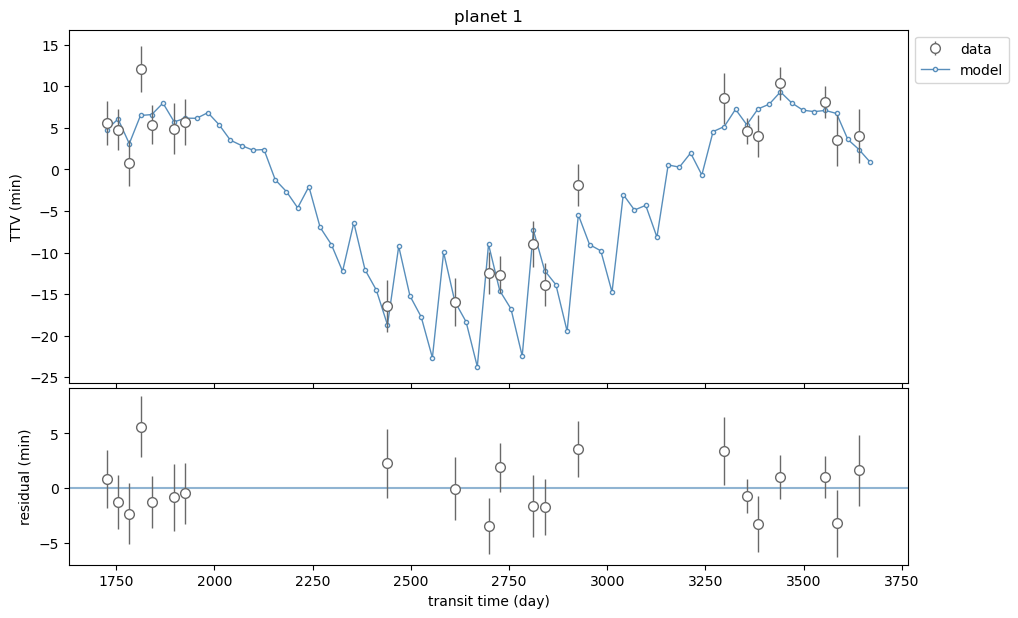

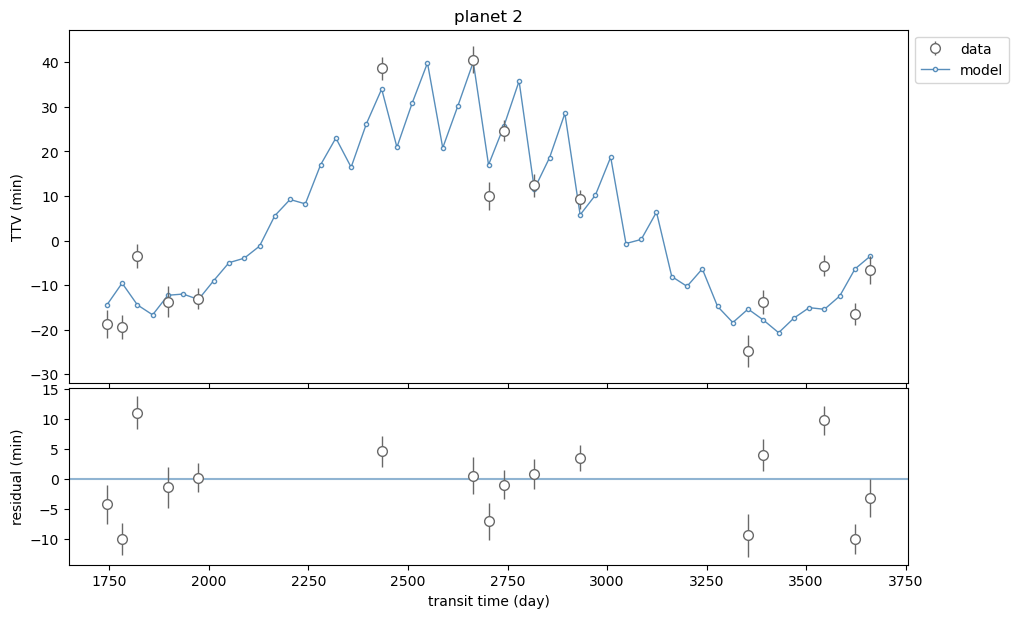

In [86]:
### plot fit
tcall = jttv.get_transit_times_all_list(popt,truncate=False)
jttv.plot_model(tcall, marker='.')
plt.show()

# fractional energy error (symplectic, dt=9.00e-01): -2.02e-09
# fractional energy error (symplectic, dt=2.86e-02): -6.39e-12
# max difference in tc: 9.19e-05 days (7.94 sec)


sample: 100%|█| 1000/1000 [00:00<00:00, 2064.67it/s, 3 steps of size 2.87e-01. a



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      lndf      1.96      1.08      1.68      0.54      3.98     76.46      1.01
     lnvar      0.54      0.44      0.58     -0.29      1.15     93.09      1.00

Number of divergences: 0


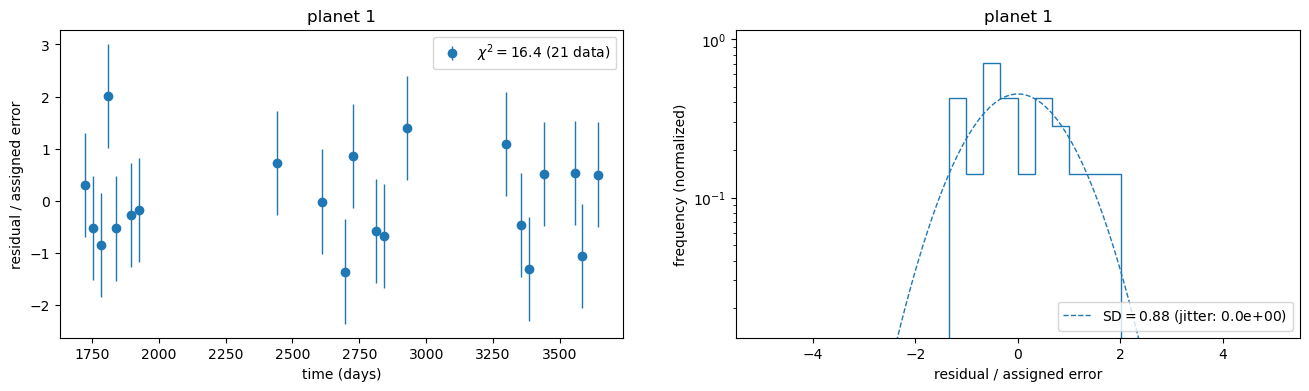

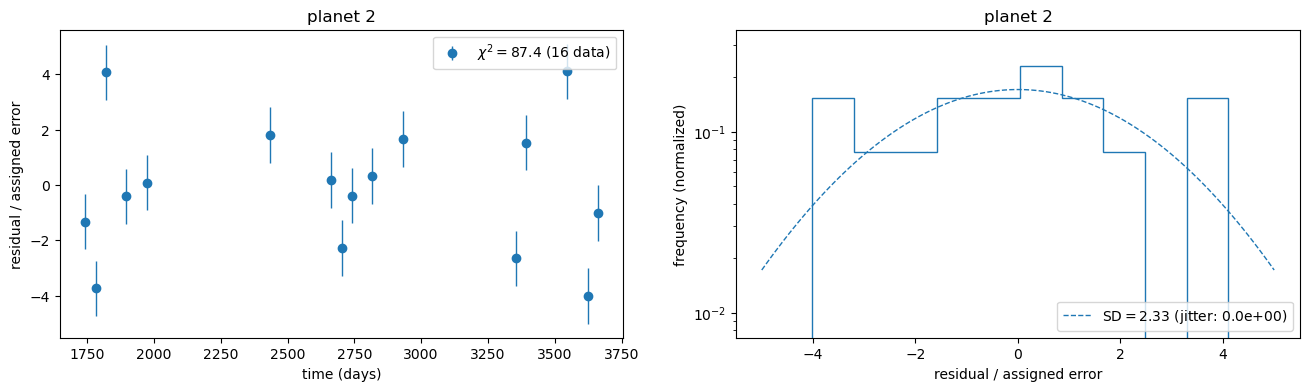

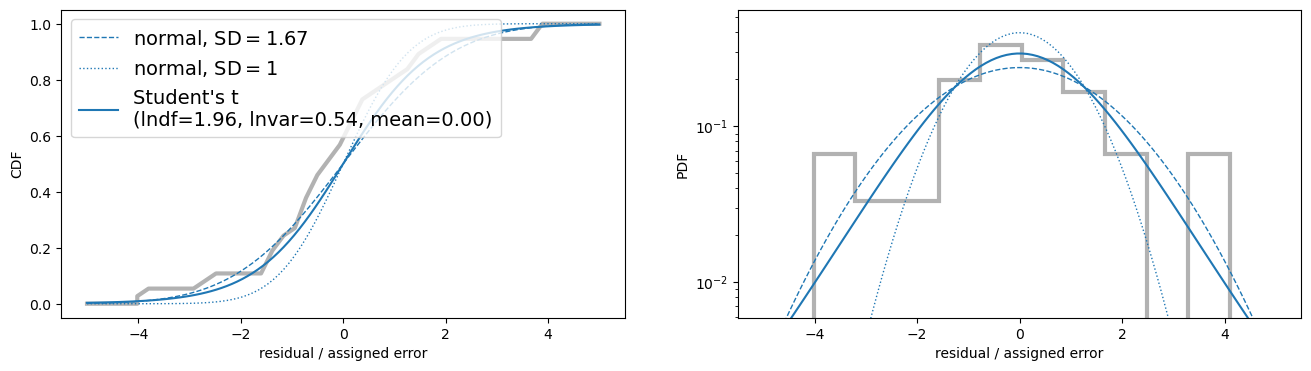

In [87]:
### check precision and residuals 
tc, _ = jttv.check_timing_precision(popt)

pdic_normal, pdic_student = jttv.check_residuals(popt)
plt.show()

In [89]:
def model_scaled(sample_keys, param_bounds):
    """numpyro model for scaled parameters"""
    par = {}

    # sample parameters from priors
    for key in sample_keys:
        par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds[key][0]*0, param_bounds[key][0]*0+1.))
        par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds[key][1] - param_bounds[key][0]) + param_bounds[key][0])
    if "pmass" not in sample_keys:
        par["pmass"] = numpyro.deterministic("pmass", jnp.exp(par["lnpmass"]))
    
    # Jacobian for uniform ecc prior
    ecc = numpyro.deterministic("ecc", jnp.sqrt(par['ecosw']**2+par['esinw']**2))
    numpyro.factor("eprior", -jnp.log(ecc))

    # compute transit times
    tcmodel, ediff = jttv.get_transit_times_obs(par)
    numpyro.deterministic("ediff", ediff)
    numpyro.deterministic("tcmodel", tcmodel)
    
    # likelihood
    tcerrmodel = jttv.errorobs_flatten     
    numpyro.sample("obs", dist.Normal(loc=tcmodel, scale=tcerrmodel), obs=jttv.tcobs_flatten)

In [90]:
# physical parameters to sample from
sample_keys = ["ecosw", "esinw", "pmass", "period", "tic"] # uniform mass prior

In [91]:
# scaled parameters
pdic_scaled = scale_pdic(popt, param_bounds)

In [92]:
kernel = NUTS(model_scaled, 
            init_strategy=init_to_value(values=pdic_scaled), 
            dense_mass=True,
            #regularize_mass_matrix=False # this speeds up sampling for unknown reason
            )

In [93]:
mcmc = MCMC(kernel, num_warmup=50, num_samples=150, num_chains=num_chains)

In [94]:
# 4hr30min on M1 mac studio
rng_key = random.PRNGKey(0)
mcmc.run(rng_key, sample_keys, param_bounds, extra_fields=('potential_energy', 'num_steps', 'adapt_state'))

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [95]:
mcmc.print_summary()


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.07      0.02      0.07      0.03      0.11      6.54      1.70
 ecosw_scaled[1]      0.14      0.02      0.14      0.09      0.17      6.16      1.70
 esinw_scaled[0]      0.06      0.04      0.05      0.02      0.11      5.39      1.60
 esinw_scaled[1]      0.13      0.03      0.12      0.09      0.17      5.47      1.59
period_scaled[0]      0.50      0.00      0.50      0.50      0.50      8.07      1.25
period_scaled[1]      0.50      0.00      0.50      0.50      0.50      4.49      1.43
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02     16.96      1.16
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.02     21.34      1.16
   tic_scaled[0]      0.50      0.01      0.50      0.49      0.51     39.70      1.05
   tic_scaled[1]      0.53      0.01      0.53      0.51      0.55     34.85      1.11

Number of divergences: 0


## Plot residuals side by side 

In [80]:
import pickle

# Load the data
with open("1339_data.pkl", "rb") as f:
    ttv_data = pickle.load(f)

# Access individual arrays
tc_lin_obs_2 = ttv_data['tc_lin_obs_2']
omc_2 = ttv_data['omc_2']
ttv_model_2 = ttv_data['ttv_model_2']
residuals_2 = ttv_data["residuals_2"]
tc_err_2 = ttv_data['tc_err_2']
indices_2 = ttv_data['indices_2']

tc_lin_obs_3 = ttv_data['tc_lin_obs_3']
omc_3 = ttv_data['omc_3']
ttv_model_3 = ttv_data['ttv_model_3']
residuals_3 = ttv_data["residuals_3"]
tc_err_3 = ttv_data['tc_err_3']
indices_3 = ttv_data['indices_3']

In [81]:
print(tcall)

[Array([1726.05374099, 1754.6349292 , 1783.21316357, 1811.79581401,
       1840.37618867, 1868.95744363, 1897.53617009, 1926.11677911,
       1954.69706244, 1983.27783242, 2011.85711967, 2040.43613018,
       2069.01597304, 2097.5958866 , 2126.17622872, 2154.75400594,
       2183.33330887, 2211.9122502 , 2240.49431852, 2269.07121073,
       2297.65007228, 2326.22813236, 2354.81248565, 2383.38885132,
       2411.96746264, 2440.54483489, 2469.13169691, 2497.707854  ,
       2526.28639912, 2554.86328203, 2583.45237479, 2612.02856586,
       2640.60717305, 2669.18372198, 2697.77423499, 2726.35066281,
       2754.9294362 , 2783.50579621, 2812.09659595, 2840.67352616,
       2869.25264731, 2897.8290572 , 2926.41907185, 2954.99688507,
       2983.57666521, 3012.15351364, 3040.74195979, 3069.320962  ,
       3097.90165221, 3126.4792946 , 3155.06562113, 3183.64573222,
       3212.22721023, 3240.805673  , 3269.38959105, 3297.97031435,
       3326.55205021, 3355.13105647, 3383.71267149, 3412.2933

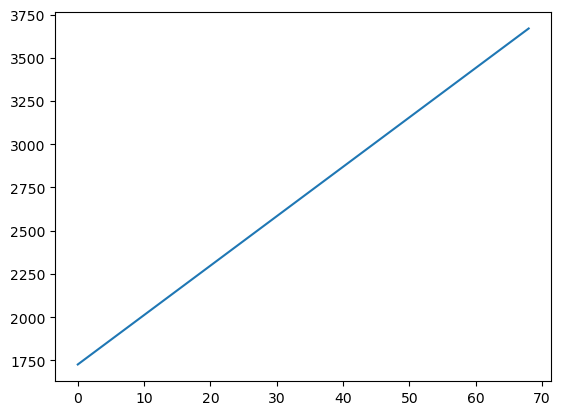

In [88]:
plt.plot(tcall[0])